In [2]:
from langchain_groq import ChatGroq
import os
from load_dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from langchain_core.output_parsers import StrOutputParser, PydanticOutputParser

load_dotenv()

if os.environ.get("GROQ_API_KEY"):
    print("API KEY FETCHED")
else:
    raise ValueError("GROQ_API_KEY Not Found!!")

llm_groq = init_chat_model(model = "llama-3.1-8b-instant", model_provider="groq")

llm_groq.invoke("What is my name?")

API KEY FETCHED


AIMessage(content="I don't have any information about your name as our conversation just started. I'm happy to chat with you, though. If you'd like to share your name, I can use it to address you in our conversation.", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 46, 'prompt_tokens': 40, 'total_tokens': 86, 'completion_time': 0.060768873, 'completion_tokens_details': None, 'prompt_time': 0.001836851, 'prompt_tokens_details': None, 'queue_time': 0.159840447, 'total_time': 0.062605724}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_7ccc667439', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d57d0-c47f-7120-9489-0ecdf36440b6-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 40, 'output_tokens': 46, 'total_tokens': 86})

# **TOOLS**

In [13]:
#Tool 1 - News Search

from langchain_community.tools import DuckDuckGoSearchRun

search_tool = DuckDuckGoSearchRun(description="This is a tool to search the web for news")

search_tool.invoke("Who is Harsh Heralgi?")

"I am a Junior Software Developer with hands-on experience in backend web application development using PHP (Laravel), SQL, and JavaScript.Aspiring software developer and ECE student with a passion for web development and IoT. Skilled in C & Python. -harshheralgi.See photos and videos from friends on Instagram, and discover other accounts you'll love.HarshHeralgiis on Facebook. Join Facebook to connect withHarshHeralgiand others you may know. Facebook gives people the power to share and makes the...79 2 Comments 3w CongratsHarshChetan! 🎉 Reply 1 Reaction 3w CongratsHarshChetan! 🎉 Reply 1 Reaction See more comments 22 PostsJul 27, 2025 ·3. Mr.HarshHeralgi, Past-Chair, IEEE SB, and his team have conducted the session. 4. Ms. Akshata Bagewadi, SB Chair, welcomed the members and briefed about the technical session. 5. Dr. Arun L. Kakhandki, SB Counselor, thanked all the office bearers and student members for volunteering and supporting the technical event.Harsh-Heralgihas one repository av

In [14]:
# Tool 2 - Wikipedia Search Tool

from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

wikipedia_tool = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper(), description="This tool is to search Wikipedia!")

wikipedia_tool.invoke("What is the capital of India?")

'Page: Delhi\nSummary: Delhi, officially the National Capital Territory (NCT) of Delhi, is a megacity and a union territory of India containing New Delhi, the capital of India. Straddling the Yamuna river, but spread chiefly to the west, or beyond its right bank, Delhi shares borders with the state of Uttar Pradesh in the east and with the state of Haryana in the remaining directions. Delhi became a union territory on 1 November 1956 and the NCT in 1995. The NCT covers an area of 1,484 square kilometres (573 sq mi). According to the 2011 census, Delhi\'s city proper population was over 11 million, while the NCT\'s population was about 16.8 million.\nThe topography of the medieval fort Purana Qila on the banks of the river Yamuna matches the literary description of the citadel Indraprastha in the Sanskrit epic Mahabharata; however, excavations in the area have revealed no signs of an ancient built environment.\nFrom the early 13th century until the mid-19th century, Delhi was the capita

In [15]:
# Custom Enterprise Tool

from langchain.tools import tool

@tool

def enterprise_tool(query:str)->str:

    """This is a tool to send emails to employees"""
    return "Email Sent!"

In [16]:

Toolkit = [search_tool, wikipedia_tool, enterprise_tool]
Toolkit

[DuckDuckGoSearchRun(description='This is a tool to search the web for news', api_wrapper=DuckDuckGoSearchAPIWrapper(region='wt-wt', safesearch='moderate', time='y', max_results=5, backend='auto', source='text')),
 WikipediaQueryRun(description='This tool is to search Wikipedia!', api_wrapper=WikipediaAPIWrapper(wiki_client=<module 'wikipedia' from 'f:\\LangChain_Tutorial\\.venv\\Lib\\site-packages\\wikipedia\\__init__.py'>, top_k_results=3, lang='en', load_all_available_meta=False, doc_content_chars_max=4000)),
 StructuredTool(name='enterprise_tool', description='This is a tool to send emails to employees', args_schema=<class 'langchain_core.utils.pydantic.enterprise_tool'>, func=<function enterprise_tool at 0x0000023EDD93B7E0>)]

# **ReAct Agent**

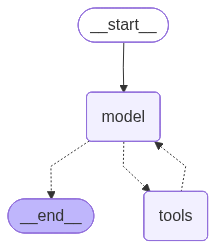

In [57]:
from langchain import tools
from langchain.agents import create_agent
from langchain_groq import ChatGroq

model = ChatGroq(
    model = "llama-3.3-70b-versatile",
    temperature=0,
    max_tokens=1000,
    timeout=30
)

agent = create_agent(model, tools=Toolkit)
agent

# **ReAct Agent Invoke With Streams**

In [ ]:
example_query = "Give me the latest news about stock market"

events = agent.stream(
    {"messages": [("user", example_query)]},
    stream_mode="values",
)
for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Give me the latest news about stock market
================================== Ai Message ==================================
Tool Calls:
  duckduckgo_search (7fegkcrc5)
 Call ID: 7fegkcrc5
  Args:
    query: latest stock market news
================================= Tool Message =================================
Name: duckduckgo_search

Find thelateststockmarketnewsfrom every corner of the globe at Reuters.com, your online source for breaking internationalmarketand financenews StockMarketToday: The Dow Jones index rockets higher Tuesday on President Trump'slatestIran war comments. Palantir makes a big move. In-depthmarketanalysis, real-timestockmarketdata, research and earnings from CNBC.com. See thelateston USStocks. From breakingnewsto in-depth reporting, Bloomberg tracks the full story in real time. Our real-timestockmarketnewsfeed automatically updates to show thelatest50 breakingmarketalerts.StockTita

# **Manually Binding The LLM With Tools**

In [ ]:
#Without Binding
llm_groq.invoke("Give me latest news about stock market!")

AIMessage(content="I'll do my best to provide you with the latest news and information about the stock market. However, please note that my knowledge cutoff is December 2023, so some of the information may not be up to date.\n\n**Market Overview:**\n\nAs of my knowledge cutoff, the global stock market was experiencing a mix of trends. The US stock market, represented by the S&P 500, was up around 15% year-to-date (YTD) in 2023. The tech-heavy Nasdaq Composite was up around 20% YTD, driven by strong performances from companies like Amazon, Microsoft, and Alphabet (Google).\n\n**Global Market Trends:**\n\n1. **Interest Rates:** Central banks worldwide were raising interest rates to combat inflation, which had a negative impact on growth stocks and companies with high debt levels.\n2. **Commodities:** Oil prices were volatile, with Brent crude prices ranging from $70 to $120 per barrel in 2023. Higher oil prices negatively impacted energy stocks, while benefiting producers.\n3. **Inflatio

In [18]:
#With Binding
llm_binded = llm_groq.bind_tools(Toolkit)
llm_binded.invoke("Give me latest news about stock market!")

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'qzn385sjq', 'function': {'arguments': '{"query":"stock market news"}', 'name': 'duckduckgo_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 358, 'total_tokens': 377, 'completion_time': 0.028961188, 'completion_tokens_details': None, 'prompt_time': 0.019796331, 'prompt_tokens_details': None, 'queue_time': 0.158783859, 'total_time': 0.048757519}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_7ccc667439', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d57d3-9152-7c32-ac02-3203596b2a17-0', tool_calls=[{'name': 'duckduckgo_search', 'args': {'query': 'stock market news'}, 'id': 'qzn385sjq', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 358, 'output_tokens': 19, 'total_tokens': 377})